# 🌍 Disaster NLP Intelligent System

**Natural Language Processing–Based Intelligent System for Disaster-Related Information Extraction and Automated Situation Summarization from Multisource Text Data**

Pipeline: **Disaster Text → NLP Extraction → Classification → Priority → Emergency Needs → BART Summary → Historical Analytics → Map**

In [3]:
import os
import sys
import importlib

BASE_DIR = r"C:\Users\aravi\OneDrive\Desktop\Disaster_NLP_Intelligent_System"
SRC_DIR = os.path.join(BASE_DIR, "src")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("SRC PATH:")
print(SRC_DIR)

print("\nFILE EXISTS:")
print(os.path.exists(
    os.path.join(SRC_DIR, "information_extraction.py")
))

SRC PATH:
C:\Users\aravi\OneDrive\Desktop\Disaster_NLP_Intelligent_System\src

FILE EXISTS:
True


## 1. Load the project AI modules

In [4]:
import information_extraction

print("Loaded module from:")
print(information_extraction.__file__)

print("\nFunction exists:")
print(hasattr(
    information_extraction,
    "extract_disaster_information"
))

print("\nAvailable functions:")
print([
    x for x in dir(information_extraction)
    if not x.startswith("_")
])

Loaded module from:
C:\Users\aravi\OneDrive\Desktop\Disaster_NLP_Intelligent_System\src\information_extraction.py

Function exists:
False

Available functions:
['extract_people_information', 're']


## 2. Enter disaster information

In [6]:
disaster_message = """
Severe flooding has affected several houses in Coimbatore.
Five people are trapped and residents urgently need food and
medical assistance. Rescue teams are requested immediately.

Heavy rainfall has caused water levels to rise rapidly in
several areas. Roads have been flooded and transportation
has been disrupted.

Local residents have requested emergency rescue operations.
Medical teams and food supplies are also required.

Authorities are monitoring the situation and evacuation
operations are being considered for severely affected areas.
"""

print(disaster_message)


Severe flooding has affected several houses in Coimbatore.
Five people are trapped and residents urgently need food and
medical assistance. Rescue teams are requested immediately.

Heavy rainfall has caused water levels to rise rapidly in
several areas. Roads have been flooded and transportation
has been disrupted.

Local residents have requested emergency rescue operations.
Medical teams and food supplies are also required.

Authorities are monitoring the situation and evacuation
operations are being considered for severely affected areas.



## 3. NLP information extraction

In [8]:
import os
import sys
import importlib

BASE_DIR = r"D:\python projects\Disaster_NLP_Intelligent_System"
SRC_DIR = os.path.join(BASE_DIR, "src")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Source folder:")
print(SRC_DIR)

Source folder:
D:\python projects\Disaster_NLP_Intelligent_System\src


In [9]:
import information_extraction

print("Module loaded from:")
print(information_extraction.__file__)

print(
    "Function available:",
    hasattr(
        information_extraction,
        "extract_disaster_information"
    )
)

Module loaded from:
D:\python projects\Disaster_NLP_Intelligent_System\src\information_extraction.py
Function available: False


🌍 DISASTER NLP INTELLIGENT SYSTEM
Project folder:
D:\python projects\Disaster_NLP_Intelligent_System

Dataset:
D:\python projects\Disaster_NLP_Intelligent_System\dataset\cleaned_disaster_data.csv

Dataset exists: True

🔎 LOADING NLP ENGINE
✅ spaCy English model loaded

🧠 LOADING BART SUMMARIZATION MODEL
Device: cpu


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 511/511 [00:03<00:00, 148.33it/s]


✅ BART model loaded successfully

📝 DISASTER INPUT


Severe flooding has affected several houses in Coimbatore.
Five people are trapped and residents urgently need food and
medical assistance. Rescue teams are requested immediately.

Heavy rainfall has caused water levels to rise rapidly in
several areas. Roads have been flooded and transportation
has been disrupted.

Local residents have requested emergency rescue operations.
Medical teams and food supplies are also required.

Authorities are monitoring the situation and evacuation
operations are being considered for severely affected areas.



🔎 NLP INFORMATION EXTRACTION
Disaster Type: Flood
Location: ['Coimbatore']
Date: []
Organization: ['Coimbatore']
People Trapped: 5
People Injured: 0
People Missing: 0
Deaths: 0
Emergency Needs: ['Food', 'Water', 'Medical Aid', 'Rescue']
Emergency Indicators: ['trapped', 'urgent', 'urgently', 'emergency', 'rescue', 'evacuation', 'immediate', 'immediately']
Severity: High

🤖 AI CLASSIFICATION
Cat

,Events
Disaster Type,
Flood,4070
Storm,2575
Road,2124
Water,1111
Epidemic,894
Earthquake,665
Extreme temperature,492
Mass movement (wet),461
Explosion (Industrial),458


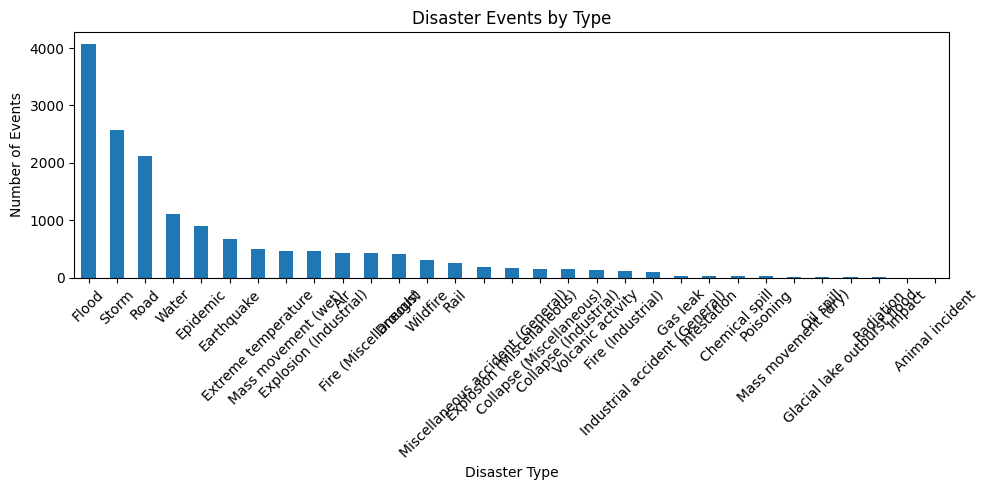

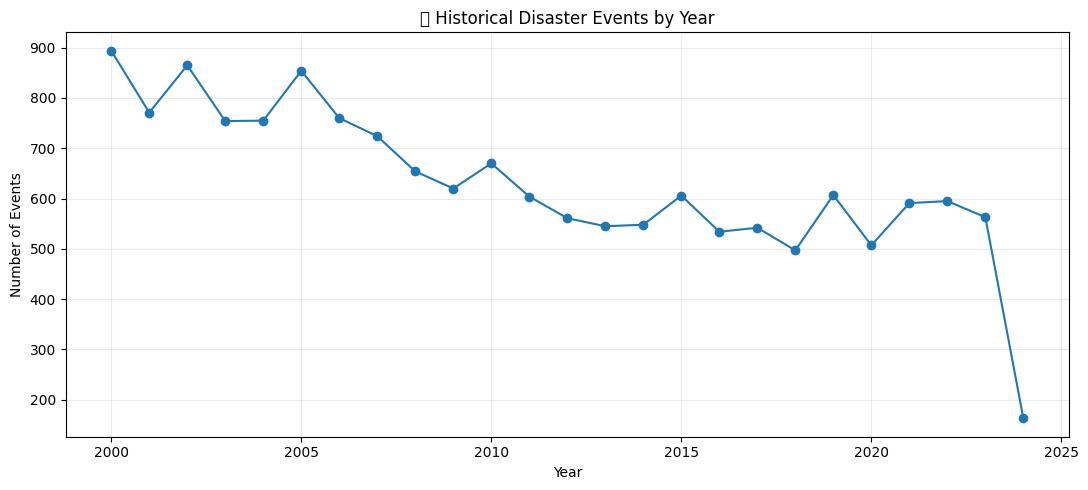


⚠️ DEATHS BY DISASTER TYPE


,Total Deaths
Disaster Type,
Earthquake,788400.0
Extreme temperature,237083.0
Storm,219999.0
Flood,132190.0
Epidemic,118149.0
Water,50336.0
Road,45910.0
Drought,24160.0
Mass movement (wet),20140.0


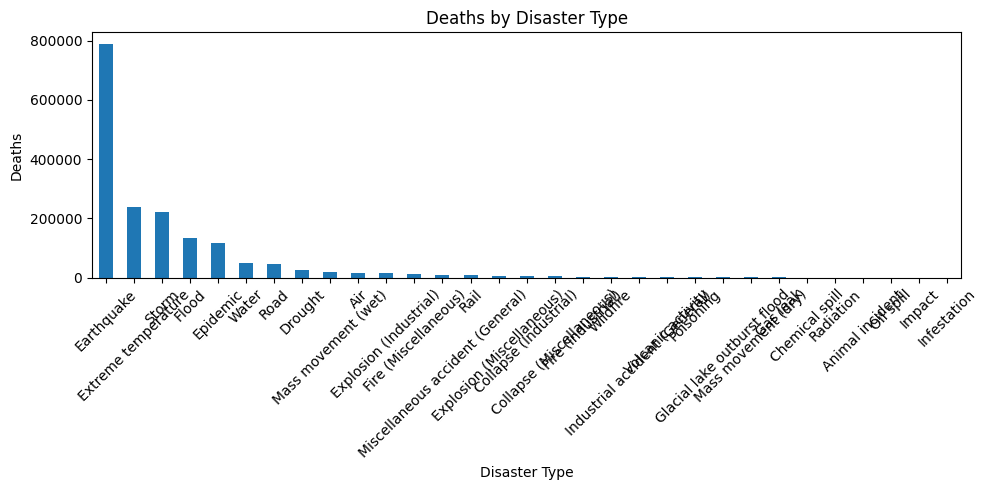

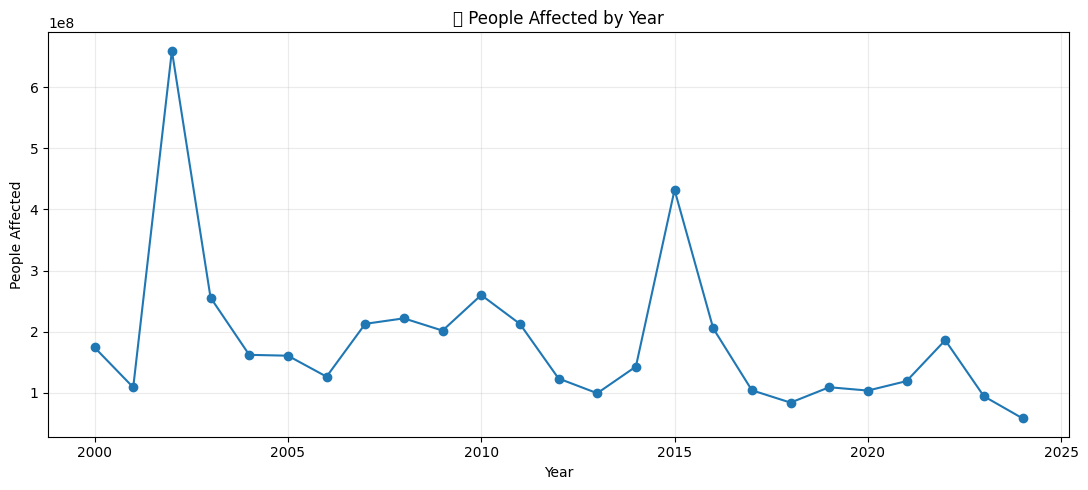


🌍 TOP 15 COUNTRIES BY DISASTER EVENTS


,Events
Country,
China,1339
India,795
United States of America,698
Indonesia,557
Philippines,455
Nigeria,428
Pakistan,314
Russian Federation,306
Democratic Republic of the Congo,296


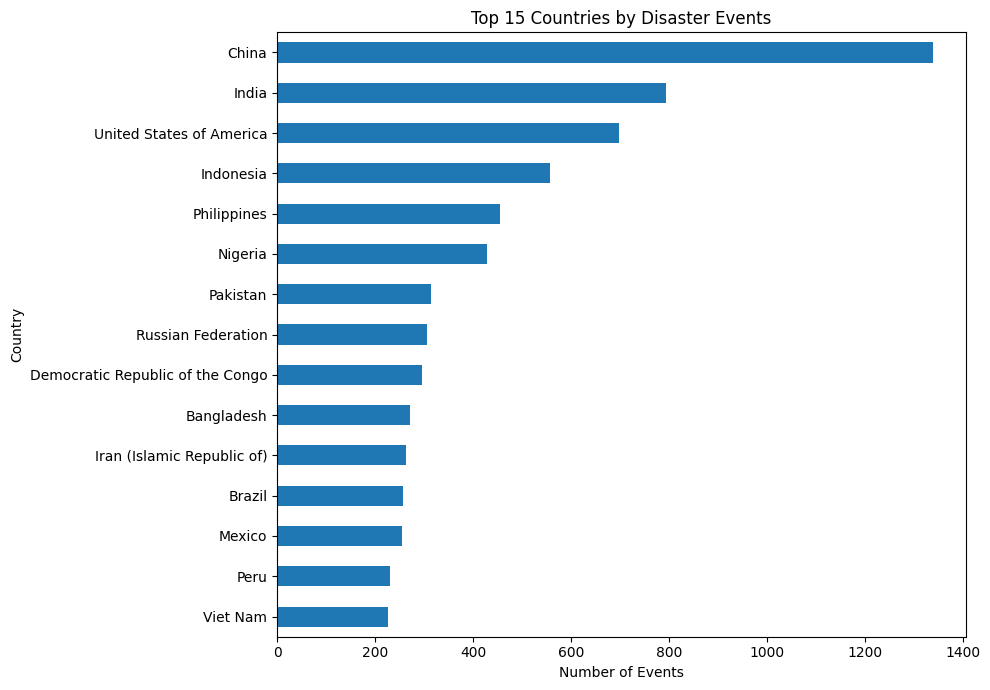

Map could not be displayed: Mime type rendering requires nbformat>=4.2.0 but it is not installed

✅ DISASTER NLP INTELLIGENT SYSTEM COMPLETED

INPUT DISASTER TEXT
        ↓
NLP INFORMATION EXTRACTION
        ↓
NAMED ENTITY RECOGNITION
        ↓
EMERGENCY DETECTION
        ↓
DISASTER CLASSIFICATION
        ↓
PRIORITY CLASSIFICATION
        ↓
EMERGENCY RESPONSE ANALYSIS
        ↓
BART AI SUMMARIZATION
        ↓
HISTORICAL DISASTER ANALYTICS
        ↓
GEOGRAPHIC VISUALIZATION



In [11]:
# ============================================================
# 🌍 DISASTER NLP INTELLIGENT SYSTEM
# COMPLETE SELF-CONTAINED JUPYTER VERSION
# ============================================================

import os
import re
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

import torch


# ============================================================
# 1. PROJECT PATH
# ============================================================

BASE_DIR = r"D:\python projects\Disaster_NLP_Intelligent_System"

DATA_FILE = os.path.join(
    BASE_DIR,
    "dataset",
    "cleaned_disaster_data.csv"
)

print("=" * 70)
print("🌍 DISASTER NLP INTELLIGENT SYSTEM")
print("=" * 70)

print("Project folder:")
print(BASE_DIR)

print("\nDataset:")
print(DATA_FILE)

print("\nDataset exists:", os.path.exists(DATA_FILE))


# ============================================================
# 2. LOAD SPACY
# ============================================================

print("\n" + "=" * 70)
print("🔎 LOADING NLP ENGINE")
print("=" * 70)

try:

    nlp = spacy.load(
        "en_core_web_sm"
    )

    print("✅ spaCy English model loaded")

except Exception:

    print(
        "❌ spaCy model not found."
    )

    print(
        "Run this in Command Prompt:"
    )

    print(
        "python -m spacy download en_core_web_sm"
    )

    raise


# ============================================================
# 3. KNOWN LOCATIONS
# ============================================================

KNOWN_LOCATIONS = [

    "Coimbatore",
    "Chennai",
    "Madurai",
    "Trichy",
    "Tiruchirappalli",
    "Salem",
    "Erode",
    "Tiruppur",
    "Dindigul",
    "Thanjavur",
    "Cuddalore",
    "Nagapattinam",
    "Kanyakumari",
    "Thoothukudi",
    "Tirunelveli",
    "Vellore",

    "Tamil Nadu",
    "Kerala",
    "Karnataka",
    "Andhra Pradesh",
    "Telangana",

    "Hyderabad",
    "Bengaluru",
    "Mumbai",
    "Delhi",

    "India",
    "Maharashtra",
    "Odisha",
    "West Bengal",
    "Assam",
    "Bihar",
    "Uttar Pradesh"
]


# ============================================================
# 4. DISASTER KEYWORDS
# ============================================================

DISASTER_KEYWORDS = {

    "Flood": [
        "flood",
        "flooding",
        "flooded",
        "heavy rainfall",
        "water level",
        "water levels",
        "flash flood"
    ],

    "Earthquake": [
        "earthquake",
        "tremor",
        "seismic",
        "aftershock"
    ],

    "Cyclone": [
        "cyclone",
        "hurricane",
        "typhoon"
    ],

    "Storm": [
        "storm",
        "thunderstorm",
        "windstorm"
    ],

    "Landslide": [
        "landslide",
        "land slide",
        "mudslide"
    ],

    "Tsunami": [
        "tsunami"
    ],

    "Drought": [
        "drought",
        "water scarcity",
        "water shortage"
    ],

    "Wildfire": [
        "wildfire",
        "forest fire",
        "bush fire"
    ],

    "Epidemic": [
        "epidemic",
        "outbreak",
        "disease outbreak",
        "virus outbreak"
    ],

    "Fire": [
        "fire",
        "building fire",
        "house fire"
    ]
}


# ============================================================
# 5. EMERGENCY KEYWORDS
# ============================================================

EMERGENCY_KEYWORDS = [

    "trapped",
    "urgent",
    "urgently",
    "emergency",
    "need help",
    "rescue",
    "rescue needed",
    "missing",
    "collapsed",
    "injured",
    "critical",
    "danger",
    "dangerous",
    "evacuate",
    "evacuation",
    "immediate",
    "immediately",
    "stranded",
    "victims"
]


# ============================================================
# 6. EMERGENCY NEEDS
# ============================================================

EMERGENCY_NEEDS = {

    "Food": [
        "food",
        "food supplies",
        "food assistance",
        "meals"
    ],

    "Water": [
        "water",
        "drinking water",
        "safe water",
        "water supply"
    ],

    "Medical Aid": [
        "medical",
        "medical aid",
        "medical assistance",
        "doctor",
        "doctors",
        "medicine",
        "medicines",
        "hospital",
        "ambulance"
    ],

    "Rescue": [
        "rescue",
        "rescue team",
        "rescue teams",
        "rescue operation",
        "rescue operations"
    ],

    "Shelter": [
        "shelter",
        "temporary shelter",
        "shelter needed"
    ],

    "Clothing": [
        "clothing",
        "clothes",
        "blankets"
    ]
}


# ============================================================
# 7. NUMBER WORDS
# ============================================================

NUMBER_WORDS = {

    "zero": 0,
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,

    "eleven": 11,
    "twelve": 12,
    "thirteen": 13,
    "fourteen": 14,
    "fifteen": 15,
    "sixteen": 16,
    "seventeen": 17,
    "eighteen": 18,
    "nineteen": 19,
    "twenty": 20
}


def convert_number(value):

    value = str(
        value
    ).lower().strip()

    if value.isdigit():

        return int(value)

    return NUMBER_WORDS.get(
        value,
        0
    )


# ============================================================
# 8. PEOPLE EXTRACTION
# ============================================================

def extract_people(
    text,
    category
):

    words = (
        r"\d+|one|two|three|four|five|six|seven|"
        r"eight|nine|ten|eleven|twelve|thirteen|"
        r"fourteen|fifteen|sixteen|seventeen|"
        r"eighteen|nineteen|twenty"
    )

    if category == "trapped":

        patterns = [

            rf"({words})\s+people?\s+(?:are\s+)?trapped",

            rf"({words})\s+persons?\s+(?:are\s+)?trapped",

            rf"({words})\s+people?\s+trapped"
        ]

    elif category == "injured":

        patterns = [

            rf"({words})\s+people?\s+(?:are\s+)?injured",

            rf"({words})\s+persons?\s+(?:are\s+)?injured",

            rf"({words})\s+injured\s+people?"
        ]

    elif category == "missing":

        patterns = [

            rf"({words})\s+people?\s+(?:are\s+)?missing",

            rf"({words})\s+persons?\s+(?:are\s+)?missing",

            rf"({words})\s+missing\s+people?"
        ]

    else:

        patterns = [

            rf"({words})\s+(?:people?\s+)?(?:have\s+)?died",

            rf"({words})\s+deaths?",

            rf"({words})\s+people?\s+(?:are\s+)?dead",

            rf"({words})\s+fatalities?"
        ]


    for pattern in patterns:

        match = re.search(
            pattern,
            text.lower()
        )

        if match:

            return convert_number(
                match.group(1)
            )

    return 0


# ============================================================
# 9. MAIN NLP INFORMATION EXTRACTION
# ============================================================

def extract_disaster_information(
    text
):

    doc = nlp(
        text
    )

    text_lower = text.lower()


    # --------------------------------------------------------
    # Disaster Type
    # --------------------------------------------------------

    disaster_type = "Unknown"

    for dtype, keywords in DISASTER_KEYWORDS.items():

        if any(
            keyword in text_lower
            for keyword in keywords
        ):

            disaster_type = dtype

            break


    # --------------------------------------------------------
    # Location
    # --------------------------------------------------------

    locations = []

    for entity in doc.ents:

        if entity.label_ in [
            "GPE",
            "LOC",
            "FAC"
        ]:

            if entity.text not in locations:

                locations.append(
                    entity.text
                )


    for location in KNOWN_LOCATIONS:

        if location.lower() in text_lower:

            if location not in locations:

                locations.append(
                    location
                )


    # --------------------------------------------------------
    # Organization
    # --------------------------------------------------------

    organizations = []

    for entity in doc.ents:

        if entity.label_ == "ORG":

            if entity.text not in organizations:

                organizations.append(
                    entity.text
                )


    # --------------------------------------------------------
    # Dates
    # --------------------------------------------------------

    dates = []

    for entity in doc.ents:

        if entity.label_ == "DATE":

            if entity.text not in dates:

                dates.append(
                    entity.text
                )


    # --------------------------------------------------------
    # Human Impact
    # --------------------------------------------------------

    trapped = extract_people(
        text,
        "trapped"
    )

    injured = extract_people(
        text,
        "injured"
    )

    missing = extract_people(
        text,
        "missing"
    )

    deaths = extract_people(
        text,
        "deaths"
    )


    # --------------------------------------------------------
    # Emergency Indicators
    # --------------------------------------------------------

    emergency_indicators = []

    for keyword in EMERGENCY_KEYWORDS:

        if keyword in text_lower:

            if keyword not in emergency_indicators:

                emergency_indicators.append(
                    keyword
                )


    # --------------------------------------------------------
    # Emergency Needs
    # --------------------------------------------------------

    emergency_needs = []

    for need, keywords in EMERGENCY_NEEDS.items():

        if any(
            keyword in text_lower
            for keyword in keywords
        ):

            emergency_needs.append(
                need
            )


    # --------------------------------------------------------
    # Severity
    # --------------------------------------------------------

    if (
        deaths > 0
        or trapped > 0
        or missing > 0
        or injured >= 5
        or len(emergency_indicators) >= 3
    ):

        severity = "High"

    elif (
        injured > 0
        or len(emergency_indicators) >= 1
    ):

        severity = "Medium"

    else:

        severity = "Low"


    return {

        "Disaster Type":
            disaster_type,

        "Location":
            locations,

        "Date":
            dates,

        "Organization":
            organizations,

        "People Trapped":
            trapped,

        "People Injured":
            injured,

        "People Missing":
            missing,

        "Deaths":
            deaths,

        "Emergency Needs":
            emergency_needs,

        "Emergency Indicators":
            emergency_indicators,

        "Severity":
            severity
    }


# ============================================================
# 10. DISASTER CLASSIFICATION
# ============================================================

def classify_disaster(
    text
):

    text_lower = text.lower()


    emergency_words = [
        word
        for word in EMERGENCY_KEYWORDS
        if word in text_lower
    ]


    relief_words = [
        "relief",
        "relief camp",
        "relief materials",
        "assistance provided",
        "aid distributed",
        "food distributed"
    ]


    damage_words = [
        "damage",
        "damaged",
        "destroyed",
        "houses",
        "roads",
        "buildings",
        "property",
        "loss"
    ]


    if len(emergency_words) >= 1:

        category = "Emergency Request"

        confidence = 0.95


    elif any(
        word in text_lower
        for word in relief_words
    ):

        category = "Relief Update"

        confidence = 0.90


    elif any(
        word in text_lower
        for word in damage_words
    ):

        category = "Damage Report"

        confidence = 0.82


    else:

        category = "General Information"

        confidence = 0.75


    return {

        "category":
            category,

        "confidence":
            confidence,

        "signals":
            emergency_words
    }


# ============================================================
# 11. PRIORITY CLASSIFICATION
# ============================================================

def classify_priority(
    text,
    extracted
):

    if (

        extracted["Deaths"] > 0

        or

        extracted["People Trapped"] > 0

        or

        extracted["People Missing"] > 0

        or

        extracted["Severity"] == "High"

    ):

        return "High"


    if (

        extracted["People Injured"] > 0

        or

        extracted["Severity"] == "Medium"

    ):

        return "Medium"


    return "Low"


# ============================================================
# 12. LOAD BART
# ============================================================

print("\n" + "=" * 70)
print("🧠 LOADING BART SUMMARIZATION MODEL")
print("=" * 70)

MODEL_NAME = "facebook/bart-large-cnn"


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    device
)


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

bart_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

bart_model = bart_model.to(
    device
)

print(
    "✅ BART model loaded successfully"
)


# ============================================================
# 13. SUMMARY FUNCTION
# ============================================================

def generate_summary(
    text
):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }


    with torch.no_grad():

        summary_ids = bart_model.generate(

            **inputs,

            max_length=130,

            min_length=30,

            num_beams=4,

            early_stopping=True,

            no_repeat_ngram_size=3
        )


    summary = tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )


    return summary


# ============================================================
# 14. DISASTER INPUT
# ============================================================

disaster_message = """

Severe flooding has affected several houses in Coimbatore.
Five people are trapped and residents urgently need food and
medical assistance. Rescue teams are requested immediately.

Heavy rainfall has caused water levels to rise rapidly in
several areas. Roads have been flooded and transportation
has been disrupted.

Local residents have requested emergency rescue operations.
Medical teams and food supplies are also required.

Authorities are monitoring the situation and evacuation
operations are being considered for severely affected areas.

"""


print("\n" + "=" * 70)
print("📝 DISASTER INPUT")
print("=" * 70)

print(
    disaster_message
)


# ============================================================
# 15. RUN NLP
# ============================================================

print("\n" + "=" * 70)
print("🔎 NLP INFORMATION EXTRACTION")
print("=" * 70)


extracted = extract_disaster_information(
    disaster_message
)


for key, value in extracted.items():

    print(
        f"{key}: {value}"
    )


# ============================================================
# 16. CLASSIFICATION
# ============================================================

classification = classify_disaster(
    disaster_message
)


priority = classify_priority(
    disaster_message,
    extracted
)


print("\n" + "=" * 70)
print("🤖 AI CLASSIFICATION")
print("=" * 70)


print(
    "Category   :",
    classification["category"]
)

print(
    "Confidence :",
    f"{classification['confidence'] * 100:.1f}%"
)

print(
    "Signals    :",
    classification["signals"]
)

print(
    "Priority   :",
    priority
)


# ============================================================
# 17. BART SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("🧠 AI-GENERATED SITUATION SUMMARY")
print("=" * 70)


summary = generate_summary(
    disaster_message
)


print(
    summary
)


# ============================================================
# 18. EMERGENCY RESPONSE
# ============================================================

print("\n" + "=" * 70)
print("🆘 EMERGENCY RESPONSE RECOMMENDATION")
print("=" * 70)


needs = extracted[
    "Emergency Needs"
]


if needs:

    print(
        "\nImmediate Requirements:"
    )

    for need in needs:

        print(
            "🔴",
            need
        )


print(
    "\nSuggested Response Actions:"
)


actions = []


if extracted[
    "People Trapped"
] > 0:

    actions.append(
        "🚑 Deploy rescue teams immediately"
    )


if extracted[
    "People Injured"
] > 0:

    actions.append(
        "🏥 Deploy medical assistance"
    )


if "Medical Aid" in needs:

    actions.append(
        "🩺 Arrange emergency medical supplies"
    )


if "Food" in needs:

    actions.append(
        "🍱 Arrange emergency food supplies"
    )


if "Water" in needs:

    actions.append(
        "💧 Arrange safe drinking water"
    )


if "Shelter" in needs:

    actions.append(
        "🏕️ Arrange temporary shelter"
    )


if priority == "High":

    actions.append(
        "📢 Escalate incident for emergency-authority attention"
    )


for action in actions:

    print(
        action
    )


# ============================================================
# 19. FINAL AI REPORT
# ============================================================

print("\n" + "=" * 70)
print("🌍 FINAL AI SITUATION REPORT")
print("=" * 70)


location_text = ", ".join(
    extracted["Location"]
)

print(
    f"""
🌪️ Disaster Type : {extracted['Disaster Type']}
📍 Location      : {location_text}
🚨 Category      : {classification['category']}
⚠️ Priority      : {priority}
🤖 Confidence    : {classification['confidence'] * 100:.1f}%

👥 People Trapped : {extracted['People Trapped']}
🏥 People Injured : {extracted['People Injured']}
❓ People Missing : {extracted['People Missing']}
⚠️ Deaths         : {extracted['Deaths']}

🆘 Emergency Needs:
{', '.join(extracted['Emergency Needs'])}

🧠 AI SUMMARY:
{summary}
"""
)


# ============================================================
# 20. LOAD HISTORICAL DATA
# ============================================================

print("\n" + "=" * 70)
print("📊 HISTORICAL DISASTER ANALYTICS")
print("=" * 70)


df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8"
)


print(
    "Total records:",
    len(df)
)

print(
    "Total columns:",
    len(df.columns)
)


# ============================================================
# 21. HISTORICAL KPIs
# ============================================================

total_events = len(
    df
)


if "Total Deaths" in df.columns:

    total_deaths = pd.to_numeric(
        df["Total Deaths"],
        errors="coerce"
    ).fillna(0).sum()

else:

    total_deaths = 0


if "Total Affected" in df.columns:

    total_affected = pd.to_numeric(
        df["Total Affected"],
        errors="coerce"
    ).fillna(0).sum()

else:

    total_affected = 0


if "Total Damage ('000 US$)" in df.columns:

    total_damage = pd.to_numeric(
        df["Total Damage ('000 US$)"],
        errors="coerce"
    ).fillna(0).sum()

else:

    total_damage = 0


print(
    f"""
🌪️ Disaster Events : {int(total_events):,}
⚠️ Total Deaths    : {int(total_deaths):,}
👥 Total Affected  : {int(total_affected):,}
💰 Damage ('000 $) : {int(total_damage):,}
"""
)


# ============================================================
# 22. DISASTER TYPE CHART
# ============================================================

if "Disaster Type" in df.columns:

    type_data = (
        df[
            "Disaster Type"
        ]
        .value_counts()
    )


    print(
        "\n🌪️ DISASTER EVENTS BY TYPE"
    )

    display(
        type_data.to_frame(
            "Events"
        )
    )


    plt.figure(
        figsize=(10, 5)
    )

    type_data.plot(
        kind="bar"
    )

    plt.title(
        "Disaster Events by Type"
    )

    plt.xlabel(
        "Disaster Type"
    )

    plt.ylabel(
        "Number of Events"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 23. YEARLY TREND
# ============================================================

if "Start Year" in df.columns:

    years = pd.to_numeric(
        df["Start Year"],
        errors="coerce"
    ).dropna()


    yearly = (
        years
        .value_counts()
        .sort_index()
    )


    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        yearly.index,
        yearly.values,
        marker="o"
    )

    plt.title(
        "📈 Historical Disaster Events by Year"
    )

    plt.xlabel(
        "Year"
    )

    plt.ylabel(
        "Number of Events"
    )

    plt.grid(
        True,
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 24. DEATHS BY DISASTER TYPE
# ============================================================

if (
    "Disaster Type" in df.columns
    and
    "Total Deaths" in df.columns
):

    temp = df.copy()


    temp[
        "Total Deaths"
    ] = pd.to_numeric(
        temp[
            "Total Deaths"
        ],
        errors="coerce"
    ).fillna(0)


    death_type = (
        temp
        .groupby(
            "Disaster Type"
        )[
            "Total Deaths"
        ]
        .sum()
        .sort_values(
            ascending=False
        )
    )


    print(
        "\n⚠️ DEATHS BY DISASTER TYPE"
    )

    display(
        death_type.to_frame(
            "Total Deaths"
        )
    )


    plt.figure(
        figsize=(10, 5)
    )

    death_type.plot(
        kind="bar"
    )

    plt.title(
        "Deaths by Disaster Type"
    )

    plt.xlabel(
        "Disaster Type"
    )

    plt.ylabel(
        "Deaths"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 25. PEOPLE AFFECTED BY YEAR
# ============================================================

if (
    "Start Year" in df.columns
    and
    "Total Affected" in df.columns
):

    temp = df.copy()


    temp[
        "Start Year"
    ] = pd.to_numeric(
        temp[
            "Start Year"
        ],
        errors="coerce"
    )


    temp[
        "Total Affected"
    ] = pd.to_numeric(
        temp[
            "Total Affected"
        ],
        errors="coerce"
    ).fillna(0)


    affected_year = (
        temp
        .dropna(
            subset=[
                "Start Year"
            ]
        )
        .groupby(
            "Start Year"
        )[
            "Total Affected"
        ]
        .sum()
    )


    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        affected_year.index,
        affected_year.values,
        marker="o"
    )

    plt.title(
        "👥 People Affected by Year"
    )

    plt.xlabel(
        "Year"
    )

    plt.ylabel(
        "People Affected"
    )

    plt.grid(
        True,
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 26. TOP COUNTRIES
# ============================================================

if "Country" in df.columns:

    country_data = (
        df[
            "Country"
        ]
        .value_counts()
        .head(15)
    )


    print(
        "\n🌍 TOP 15 COUNTRIES BY DISASTER EVENTS"
    )

    display(
        country_data.to_frame(
            "Events"
        )
    )


    plt.figure(
        figsize=(10, 7)
    )

    country_data.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "Top 15 Countries by Disaster Events"
    )

    plt.xlabel(
        "Number of Events"
    )

    plt.ylabel(
        "Country"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 27. INTERACTIVE DISASTER MAP
# ============================================================

try:

    import plotly.express as px


    if (
        "Latitude" in df.columns
        and
        "Longitude" in df.columns
    ):

        map_df = df.copy()


        map_df[
            "Latitude"
        ] = pd.to_numeric(
            map_df[
                "Latitude"
            ],
            errors="coerce"
        )


        map_df[
            "Longitude"
        ] = pd.to_numeric(
            map_df[
                "Longitude"
            ],
            errors="coerce"
        )


        map_df = map_df.dropna(
            subset=[
                "Latitude",
                "Longitude"
            ]
        )


        if not map_df.empty:

            hover_columns = [
                column
                for column in [
                    "Disaster Type",
                    "Country",
                    "Location",
                    "Start Year",
                    "Total Deaths",
                    "Total Affected"
                ]
                if column in map_df.columns
            ]


            fig = px.scatter_geo(

                map_df,

                lat="Latitude",

                lon="Longitude",

                hover_data=hover_columns,

                title="🌍 Historical Disaster Locations"
            )


            fig.update_layout(
                height=650
            )


            fig.show()


except Exception as e:

    print(
        "Map could not be displayed:",
        e
    )


# ============================================================
# 28. PROJECT COMPLETED
# ============================================================

print("\n" + "=" * 70)

print(
    "✅ DISASTER NLP INTELLIGENT SYSTEM COMPLETED"
)

print("=" * 70)

print(
    """
INPUT DISASTER TEXT
        ↓
NLP INFORMATION EXTRACTION
        ↓
NAMED ENTITY RECOGNITION
        ↓
EMERGENCY DETECTION
        ↓
DISASTER CLASSIFICATION
        ↓
PRIORITY CLASSIFICATION
        ↓
EMERGENCY RESPONSE ANALYSIS
        ↓
BART AI SUMMARIZATION
        ↓
HISTORICAL DISASTER ANALYTICS
        ↓
GEOGRAPHIC VISUALIZATION
"""
)

print("=" * 70)

## 4. Human impact

In [12]:
trapped = extracted.get("People Trapped", 0)
injured = extracted.get("People Injured", 0)
missing = extracted.get("People Missing", 0)
deaths = extracted.get("Deaths", 0)

print("👥 Trapped :", trapped)
print("🏥 Injured :", injured)
print("❓ Missing :", missing)
print("⚠️ Deaths  :", deaths)

👥 Trapped : 5
🏥 Injured : 0
❓ Missing : 0
⚠️ Deaths  : 0


## 5. AI classification and priority

## 6. Emergency response analysis

In [14]:
needs = extracted.get("Emergency Needs", [])
signals = classification.get("signals", [])

actions = []

try:
    trapped_number = int(trapped)
except:
    trapped_number = 0

try:
    injured_number = int(injured)
except:
    injured_number = 0

if trapped_number > 0:
    actions.append("🚑 Deploy rescue teams immediately")

if injured_number > 0:
    actions.append("🏥 Deploy medical assistance")

if "Medical Aid" in needs:
    actions.append("🩺 Arrange emergency medical supplies")

if "Food" in needs:
    actions.append("🍱 Arrange emergency food supplies")

if "Water" in needs:
    actions.append("💧 Arrange safe drinking water")

if "Shelter" in needs:
    actions.append("🏕️ Arrange temporary shelter")

if priority == "High":
    actions.append("📢 Escalate the incident for emergency-authority attention")

if "evacuate" in signals or "evacuation" in signals:
    actions.append("🚨 Assess evacuation requirements")

print("========== EMERGENCY NEEDS ==========")
for item in needs:
    print("🔴", item)

print("\n========== RESPONSE ACTIONS ==========")
for action in actions:
    print(action)

========== EMERGENCY NEEDS ==========
🔴 Food
🔴 Water
🔴 Medical Aid
🔴 Rescue

========== RESPONSE ACTIONS ==========
🚑 Deploy rescue teams immediately
🩺 Arrange emergency medical supplies
🍱 Arrange emergency food supplies
💧 Arrange safe drinking water
📢 Escalate the incident for emergency-authority attention
🚨 Assess evacuation requirements


## 7. BART automated situation summary

In [16]:
summary = generate_summary(disaster_message)

print("🧠 GENERATED SITUATION SUMMARY")
print(summary)

🧠 GENERATED SITUATION SUMMARY
Heavy rainfall has caused water levels to rise rapidly in Coimbatore. Roads have been flooded and transportation disrupted. Five people are trapped and residents urgently need food and medical assistance.


## 8. Final AI situation report

In [17]:
disaster_type = extracted.get("Disaster Type", "Unknown")
locations = extracted.get("Location", [])

if isinstance(locations, list):
    location_text = ", ".join(locations)
else:
    location_text = str(locations)

print("=" * 65)
print("🌍 DISASTER INTELLIGENCE & RESPONSE SYSTEM")
print("=" * 65)
print("🌪️ Disaster Type :", disaster_type)
print("📍 Location      :", location_text)
print("🚨 Category      :", classification.get("category", "Unknown"))
print("⚠️ Priority      :", priority)
print("🤖 Confidence    :", f"{confidence:.2f}%")
print("👥 Trapped       :", trapped)
print("🏥 Injured       :", injured)
print("❓ Missing       :", missing)
print("⚠️ Deaths        :", deaths)
print("🆘 Needs         :", needs)
print("\n🧠 AI SUMMARY")
print(summary)
print("=" * 65)

🌍 DISASTER INTELLIGENCE & RESPONSE SYSTEM
🌪️ Disaster Type : Flood
📍 Location      : Coimbatore
🚨 Category      : Emergency Request
⚠️ Priority      : High


NameError: name 'confidence' is not defined

# 📊 Historical Disaster Analytics

In [18]:
df = pd.read_csv(DATA_FILE, encoding="utf-8")

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

Rows: 15784
Columns: 49


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update,Start Date,Severity,Disaster Text
0,1999-9388-DJI,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,Unknown,DJI,...,NaN,NaN,NaN,58.111474,"[{""adm1_code"":1093,""adm1_name"":""Ali Sabieh""},{...",2006-03-01,2023-09-25,2001-06-01,High,"Disaster: Drought. Location: Ali Sabieh, Dikhi..."
1,1999-9388-SDN,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,Unknown,SDN,...,NaN,NaN,NaN,56.514291,"[{""adm1_code"":2757,""adm1_name"":""Northern Darfu...",2006-03-08,2023-09-25,2000-01-01,High,"Disaster: Drought. Location: Northern Darfur, ..."
2,1999-9388-SOM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,Unknown,SOM,...,NaN,NaN,NaN,56.514291,"[{""adm1_code"":2691,""adm1_name"":""Bay""},{""adm1_c...",2006-03-08,2023-09-25,2000-01-01,High,"Disaster: Drought. Location: Ceel Barde, Rab D..."
3,2000-0001-AGO,No,tec-tra-roa-roa,Technological,Transport,Road,Road,NaN,Unknown,AGO,...,NaN,NaN,NaN,56.514291,NaN,2004-10-27,2023-09-25,2000-01-26,Medium,Disaster: Road. Location: Calulo. Country: Ang...
4,2000-0002-AGO,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,Unknown,AGO,...,NaN,10000.0,17695.0,56.514291,"[{""adm2_code"":4214,""adm2_name"":""Baia Farta""},{...",2005-02-03,2023-09-25,2000-01-08,Medium,Disaster: Flood. Location: Dombre Grande villa...


In [19]:
total_events = len(df)

total_deaths = (
    pd.to_numeric(df["Total Deaths"], errors="coerce").fillna(0).sum()
    if "Total Deaths" in df.columns else 0
)

total_affected = (
    pd.to_numeric(df["Total Affected"], errors="coerce").fillna(0).sum()
    if "Total Affected" in df.columns else 0
)

total_damage = (
    pd.to_numeric(df["Total Damage ('000 US$)"], errors="coerce").fillna(0).sum()
    if "Total Damage ('000 US$)" in df.columns else 0
)

print(f"🌪️ Disaster Events : {int(total_events):,}")
print(f"⚠️ Total Deaths    : {int(total_deaths):,}")
print(f"👥 Total Affected  : {int(total_affected):,}")
print(f"💰 Damage ('000 $) : {int(total_damage):,}")

🌪️ Disaster Events : 15,784
⚠️ Total Deaths    : 1,720,787
👥 Total Affected  : 4,620,248,935
💰 Damage ('000 $) : 3,523,308,909


## 9. Disaster events by type

,Events
Disaster Type,
Flood,4070
Storm,2575
Road,2124
Water,1111
Epidemic,894
Earthquake,665
Extreme temperature,492
Mass movement (wet),461
Explosion (Industrial),458


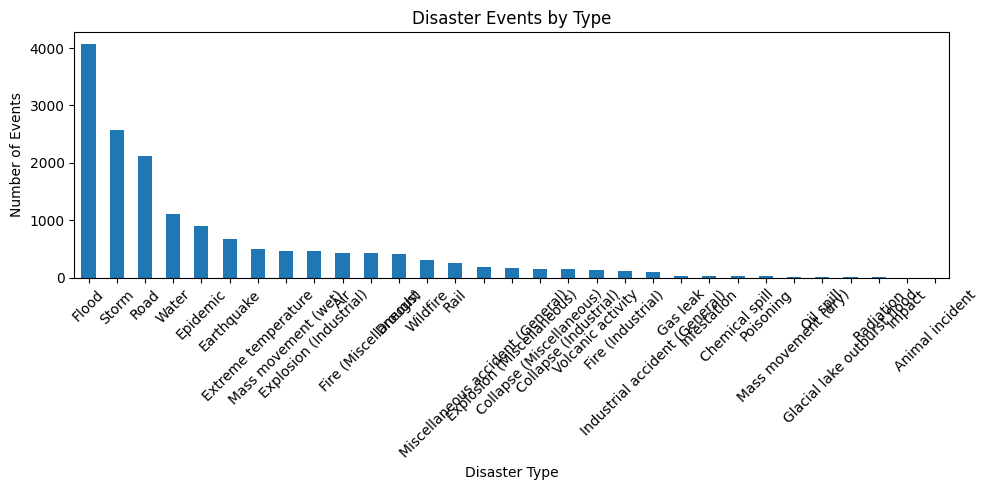

In [20]:
if "Disaster Type" in df.columns:
    type_data = df["Disaster Type"].value_counts()
    display(type_data.to_frame("Events"))

    plt.figure(figsize=(10, 5))
    type_data.plot(kind="bar")
    plt.title("Disaster Events by Type")
    plt.xlabel("Disaster Type")
    plt.ylabel("Number of Events")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Disaster events by year

,Events
Start Year,
2000,894
2001,771
2002,865
2003,754
2004,755
2005,854
2006,760
2007,724
2008,654


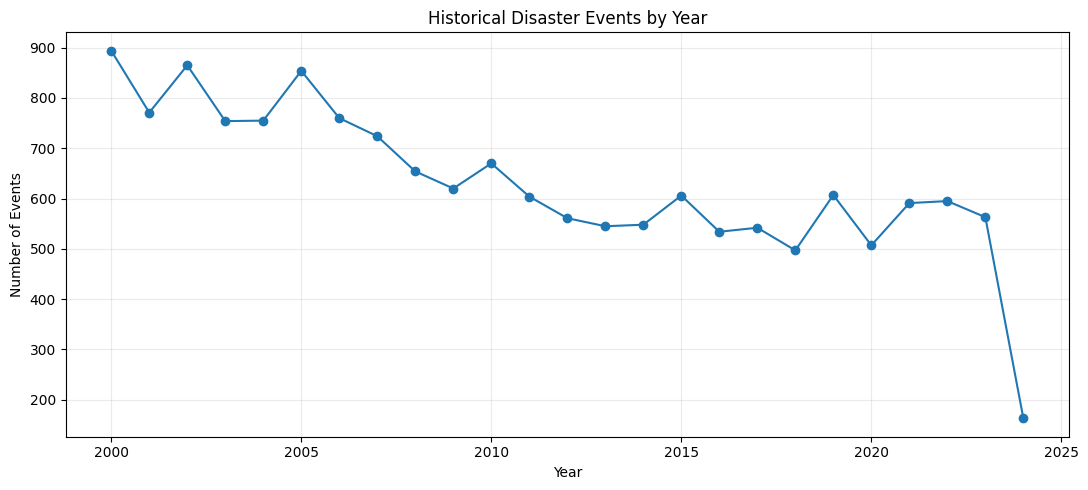

In [21]:
if "Start Year" in df.columns:
    years = pd.to_numeric(df["Start Year"], errors="coerce").dropna()
    yearly = years.value_counts().sort_index()

    display(yearly.to_frame("Events"))

    plt.figure(figsize=(11, 5))
    plt.plot(yearly.index, yearly.values, marker="o")
    plt.title("Historical Disaster Events by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Events")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## 11. Deaths by disaster type

,Total Deaths
Disaster Type,
Earthquake,788400.0
Extreme temperature,237083.0
Storm,219999.0
Flood,132190.0
Epidemic,118149.0
Water,50336.0
Road,45910.0
Drought,24160.0
Mass movement (wet),20140.0


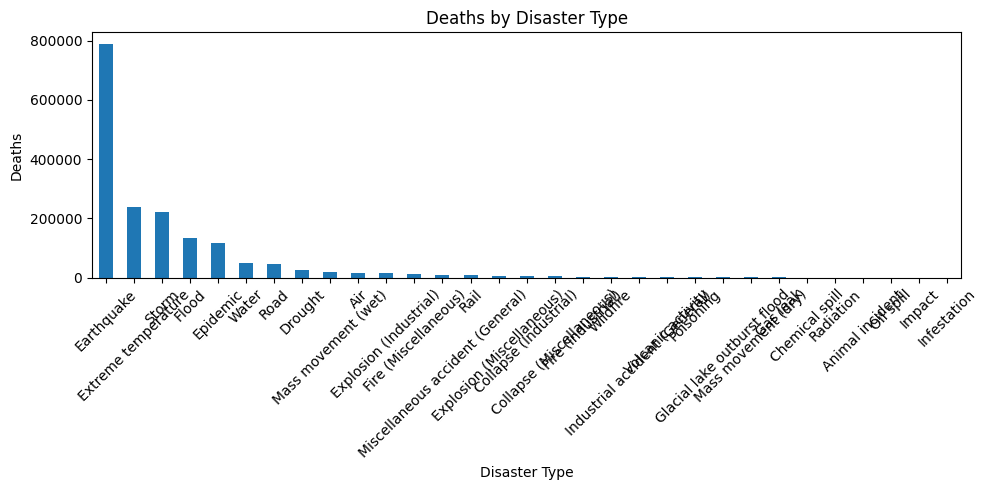

In [22]:
if "Disaster Type" in df.columns and "Total Deaths" in df.columns:
    temp = df.copy()
    temp["Total Deaths"] = pd.to_numeric(
        temp["Total Deaths"], errors="coerce"
    ).fillna(0)

    death_type = (
        temp.groupby("Disaster Type")["Total Deaths"]
        .sum()
        .sort_values(ascending=False)
    )

    display(death_type.to_frame("Total Deaths"))

    plt.figure(figsize=(10, 5))
    death_type.plot(kind="bar")
    plt.title("Deaths by Disaster Type")
    plt.xlabel("Disaster Type")
    plt.ylabel("Deaths")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 12. People affected by year

,Total Affected
Start Year,
2000,174274727.0
2001,109022629.0
2002,659461666.0
2003,255757731.0
2004,162189672.0
2005,160782980.0
2006,126502913.0
2007,212882686.0
2008,221870697.0


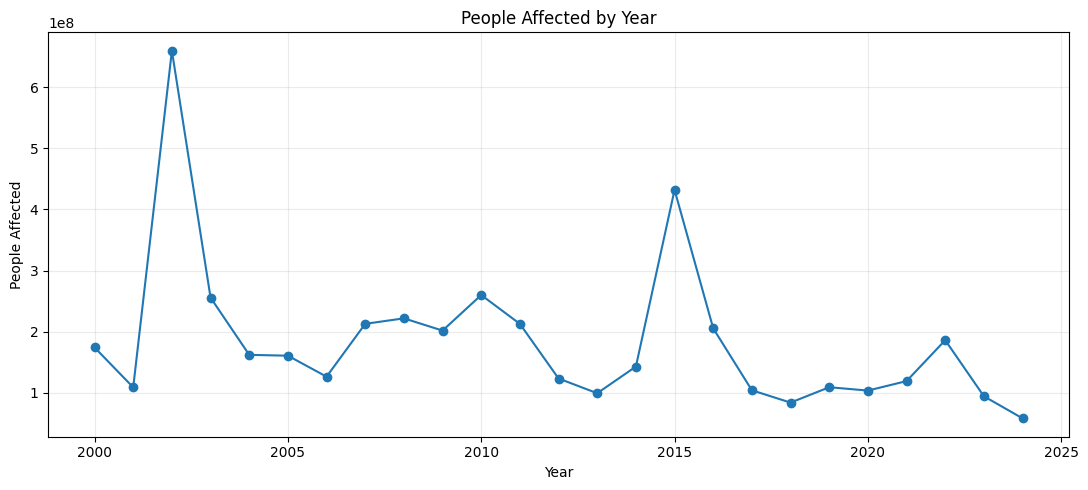

In [23]:
if "Start Year" in df.columns and "Total Affected" in df.columns:
    temp = df.copy()
    temp["Start Year"] = pd.to_numeric(temp["Start Year"], errors="coerce")
    temp["Total Affected"] = pd.to_numeric(
        temp["Total Affected"], errors="coerce"
    ).fillna(0)

    affected_year = (
        temp.dropna(subset=["Start Year"])
        .groupby("Start Year")["Total Affected"]
        .sum()
    )

    display(affected_year.to_frame("Total Affected"))

    plt.figure(figsize=(11, 5))
    plt.plot(affected_year.index, affected_year.values, marker="o")
    plt.title("People Affected by Year")
    plt.xlabel("Year")
    plt.ylabel("People Affected")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## 13. Top 15 countries

,Events
Country,
China,1339
India,795
United States of America,698
Indonesia,557
Philippines,455
Nigeria,428
Pakistan,314
Russian Federation,306
Democratic Republic of the Congo,296


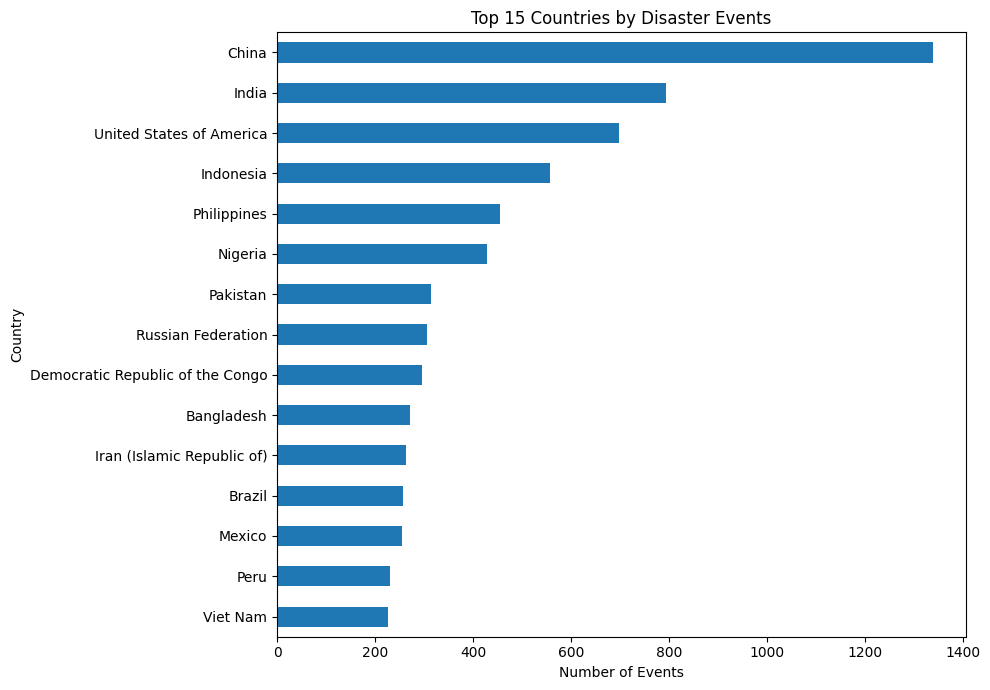

In [24]:
if "Country" in df.columns:
    country_data = df["Country"].value_counts().head(15)
    display(country_data.to_frame("Events"))

    plt.figure(figsize=(10, 7))
    country_data.sort_values().plot(kind="barh")
    plt.title("Top 15 Countries by Disaster Events")
    plt.xlabel("Number of Events")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

## 14. Interactive disaster map

# ✅ Complete Project Pipeline

**Input Disaster Text**  
↓  
**NLP Information Extraction**  
↓  
**Named Entity Recognition**  
↓  
**Emergency Detection**  
↓  
**Disaster Classification**  
↓  
**Priority Classification**  
↓  
**Emergency Response Analysis**  
↓  
**BART Situation Summarization**  
↓  
**Historical Disaster Analytics**  
↓  
**Interactive Geographic Visualization**

The same project modules can be used by both this Jupyter notebook and the Streamlit dashboard.